# Decision trees

### Twenty questions, chosen by arithmetic

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How a split is actually chosen, what Gini impurity measures, how depth trades memorisation against generalisation, and why a tree you can read is worth more than one that scores slightly better |
| **You should already know** | [Logistic regression](../01-logistic-regression/) |
| **Dataset** | UCI Dry Bean (13,611 × 16) |
| **Runtime** | Under a minute on a laptop CPU |
| **Next** | [04-01 Bagging](../../04-ensembles/01-bagging/) · [04-02 Random forests](../../04-ensembles/02-random-forest/) |

---

## 1. The idea

A decision tree plays twenty questions. *Is the area below 40,000? Then is the
perimeter below 800?* Each answer sends the bean down a branch, and the leaf it
lands in holds the prediction.

What makes it a learning algorithm rather than a flowchart somebody wrote is
that **the questions are chosen automatically**. At every node the tree tries
every feature at every threshold, scores each candidate split, and keeps the
best one. Then it recurses.

The appeal is that the result is legible. You can print a tree and read the
reasoning, which is rare enough to be worth a lot in any setting where a human
has to sign off on the decision.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y = datasets.dry_bean()
print(f"{X.shape[0]:,} beans, {X.shape[1]} measurements, {y.nunique()} varieties")

13,611 beans, 16 measurements, 7 varieties


## 2. The maths

To pick a split you need a number saying how mixed a group of beans is.
**Gini impurity** is the usual choice:

$$G = 1 - \sum_{c} p_c^2$$

where $p_c$ is the fraction of the group belonging to class $c$. A pure group of
one variety scores 0. An even mix of seven varieties scores $1 - 7 \times (1/7)^2
= 0.857$, the worst possible here.

A split takes one group and produces two. Its value is how much impurity it
removes, weighted by how many beans land on each side:

$$\Delta G = G_{\text{parent}} - \frac{n_{\text{left}}}{n}G_{\text{left}} - \frac{n_{\text{right}}}{n}G_{\text{right}}$$

The tree tries every feature and every threshold, and keeps whichever $\Delta G$
is largest. That is genuinely all there is to it: the algorithm is **greedy**,
taking the locally best split without any thought for what it makes possible
two levels down.

## 3. From scratch

Finding the single best split is short enough to write out, and it is the whole
algorithm in miniature.

In [2]:
def gini(labels):
    """Impurity of a group. 0 when pure, higher when mixed."""
    if len(labels) == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    proportions = counts / counts.sum()
    return 1.0 - np.sum(proportions ** 2)


def best_split(X, y):
    """Search every feature and every candidate threshold for the largest gain."""
    parent = gini(y)
    best = {"gain": 0.0, "feature": None, "threshold": None}

    for feature in range(X.shape[1]):
        values = X[:, feature]
        # Candidate thresholds midway between consecutive distinct values. We
        # sample 40 quantiles rather than test all 13,611, which is what
        # scikit-learn's histogram-based splitters do for the same reason.
        candidates = np.unique(np.quantile(values, np.linspace(0.02, 0.98, 40)))

        for threshold in candidates:
            left = values <= threshold
            if left.sum() == 0 or left.sum() == len(y):
                continue
            gain = (parent
                    - left.mean() * gini(y[left])
                    - (1 - left.mean()) * gini(y[~left]))
            if gain > best["gain"]:
                best = {"gain": gain, "feature": feature, "threshold": threshold}
    return best


split = best_split(X.values, y.values)
print(f"impurity before any split : {gini(y.values):.4f}")
print(f"best single question      : is {X.columns[split['feature']]} "
      f"<= {split['threshold']:,.2f} ?")
print(f"impurity removed          : {split['gain']:.4f}")

mask = X.values[:, split["feature"]] <= split["threshold"]
print(f"\nleft branch  ({mask.sum():,} beans): {y[mask].value_counts().head(3).to_dict()}")
print(f"right branch ({(~mask).sum():,} beans): {y[~mask].value_counts().head(3).to_dict()}")

impurity before any split : 0.8271
best single question      : is MajorAxisLength <= 278.90 ?
impurity removed          : 0.1423

left branch  (5,633 beans): {'DERMASON': 3340, 'SEKER': 1854, 'SIRA': 420}
right branch (7,978 beans): {'SIRA': 2216, 'HOROZ': 1913, 'CALI': 1629}


One question, chosen by arithmetic alone, already separates the small varieties
from the large ones. Repeat that recursively and you have a decision tree.

Treat that 278.90 as approximate. We scored 40 quantiles per feature rather
than all 13,611 distinct values, which is the same shortcut scikit-learn's
histogram splitters take, and it lands near the optimum rather than on it. The
tree in the next section searches exhaustively and picks 280.704 for the same
feature. The question is the finding; the third decimal place is not.

## 4. In practice

### Reading the tree

A depth-3 tree is small enough to print and check against common sense. Watch
the root split: it asks about the same feature our scratch search picked, at a
slightly different threshold, because scikit-learn tests every distinct value
and we tested 40 quantiles.

depth-3 tree, 8 leaves, training accuracy 0.7772

our 40-quantile search  : is MajorAxisLength <= 278.90 ?
scikit-learn's root     : is MajorAxisLength <= 280.704 ?


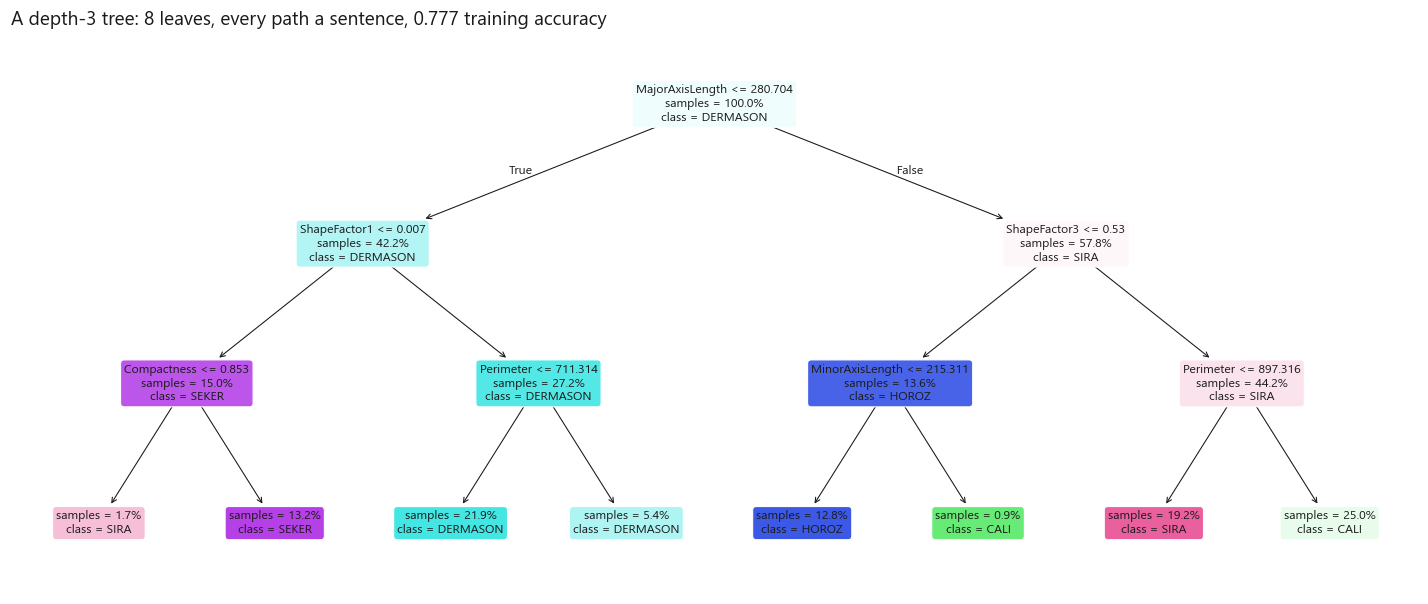

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

shallow = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X.values, y.values)

fig, ax = plt.subplots(figsize=(16.5, 6.6))
nodes = plot_tree(shallow, feature_names=list(X.columns),
                  class_names=[str(c) for c in sorted(y.unique())],
                  filled=True, rounded=True, fontsize=8, impurity=False,
                  proportion=True, ax=ax)

# The seven-element `value` array is the widest line in every box and the least
# useful one here, and with it the eight leaf boxes overlap and clip each other.
# Drop that line and the leaf row becomes legible without shrinking the type or
# rounding the thresholds away.
for node in nodes:
    node.set_text("\n".join(line for line in node.get_text().split("\n")
                            if not line.startswith("value")))

ax.set_title(f"A depth-3 tree: {shallow.get_n_leaves()} leaves, every path a "
             f"sentence, {shallow.score(X.values, y.values):.3f} training accuracy",
             loc="left", fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-the-tree.png")

print(f"depth-3 tree, {shallow.get_n_leaves()} leaves, "
      f"training accuracy {shallow.score(X.values, y.values):.4f}")

# The root split scikit-learn actually chose, against the one we found by hand.
tree_internals = shallow.tree_
print(f"\nour 40-quantile search  : is {X.columns[split['feature']]} "
      f"<= {split['threshold']:,.2f} ?")
print(f"scikit-learn's root     : is {X.columns[tree_internals.feature[0]]} "
      f"<= {tree_internals.threshold[0]:,.3f} ?")

Every path from the root to a leaf is a rule you can state in a sentence, and a
domain expert could tell you whether it makes sense. Almost nothing else in this
book offers that.

Each box shows the question, the share of beans reaching it, and the class it
would predict. The seven-number class-distribution array that `plot_tree` draws
by default has been removed: with seven varieties it is wider than everything
else in the box, and it pushed the eight leaves into each other until the text
clipped. A diagram claiming to be readable has to actually be readable.

### Depth is the whole story

Left unconstrained, a tree keeps splitting until every leaf is pure, which it
can always achieve by isolating individual beans.

depth   10: training 0.9630, held out 0.9066, 294 leaves
depth none: training 1.0000, held out 0.8860, 679 leaves

cost of letting it run free: +0.0206 held-out accuracy


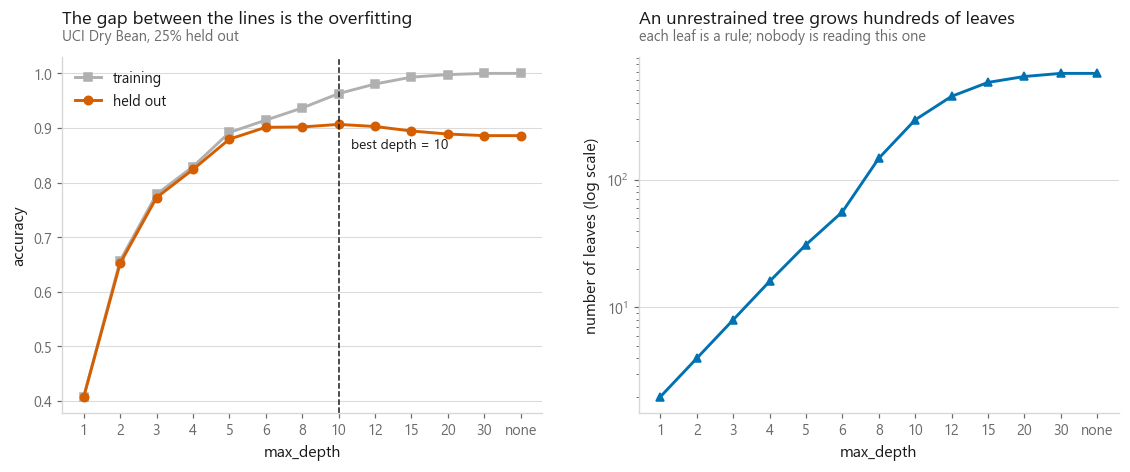

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.25, stratify=y, random_state=SEED)

depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 30, None]
train_curve, test_curve, leaf_counts = [], [], []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(X_train, y_train)
    train_curve.append(tree.score(X_train, y_train))
    test_curve.append(tree.score(X_test, y_test))
    leaf_counts.append(tree.get_n_leaves())

labels = [str(d) if d else "none" for d in depths]
positions = np.arange(len(depths))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

axes[0].plot(positions, train_curve, marker=style.MARKERS[1], color=style.NEUTRAL, label="training")
axes[0].plot(positions, test_curve, marker=style.MARKERS[0], color=style.HIGHLIGHT, label="held out")
best = int(np.argmax(test_curve))
axes[0].axvline(best, color=style.INK, ls="--", lw=1)
axes[0].annotate(f"best depth = {labels[best]}", xy=(best, test_curve[best]),
                 xytext=(8, -16), textcoords="offset points", fontsize=9, color=style.INK)
axes[0].set_xticks(positions, labels)
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("accuracy")
axes[0].legend()
style.title(axes[0], "The gap between the lines is the overfitting",
            "UCI Dry Bean, 25% held out")

axes[1].plot(positions, leaf_counts, marker=style.MARKERS[2], color=style.PALETTE[0])
axes[1].set_yscale("log")
axes[1].set_xticks(positions, labels)
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("number of leaves (log scale)")
style.title(axes[1], "An unrestrained tree grows hundreds of leaves",
            "each leaf is a rule; nobody is reading this one")

style.save(fig, FIG / "fig-02-depth.png")

print(f"depth {labels[best]:>4}: training {train_curve[best]:.4f}, held out {test_curve[best]:.4f}, "
      f"{leaf_counts[best]} leaves")
print(f"depth none: training {train_curve[-1]:.4f}, held out {test_curve[-1]:.4f}, "
      f"{leaf_counts[-1]:,} leaves")
print(f"\ncost of letting it run free: {test_curve[best] - test_curve[-1]:+.4f} held-out accuracy")

The unconstrained tree reaches a perfect 1.000 training score across hundreds of
leaves, and it is *worse* on held-out data than a tree with less than half as
many. It has memorised. This is the plainest demonstration of overfitting in the
book, because you can count the leaves it invented in order to do it.

Note also that even the best tree here loses to logistic regression on the same
data, which the comparison at the end of this notebook confirms. Dry Bean rewards
smooth linear boundaries, and a staircase is the wrong shape for it.

## 5. When it wins, when it loses

Trees split on one feature at a time, so every boundary they draw is a staircase
of axis-aligned steps. When the real boundary is diagonal, the tree must
approximate it with steps, and it needs a lot of them.

cross-validated accuracy on the full 16 features:


  logistic regression   : 0.9234


  tree, depth 6         : 0.8978


  tree, unrestrained    : 0.8945


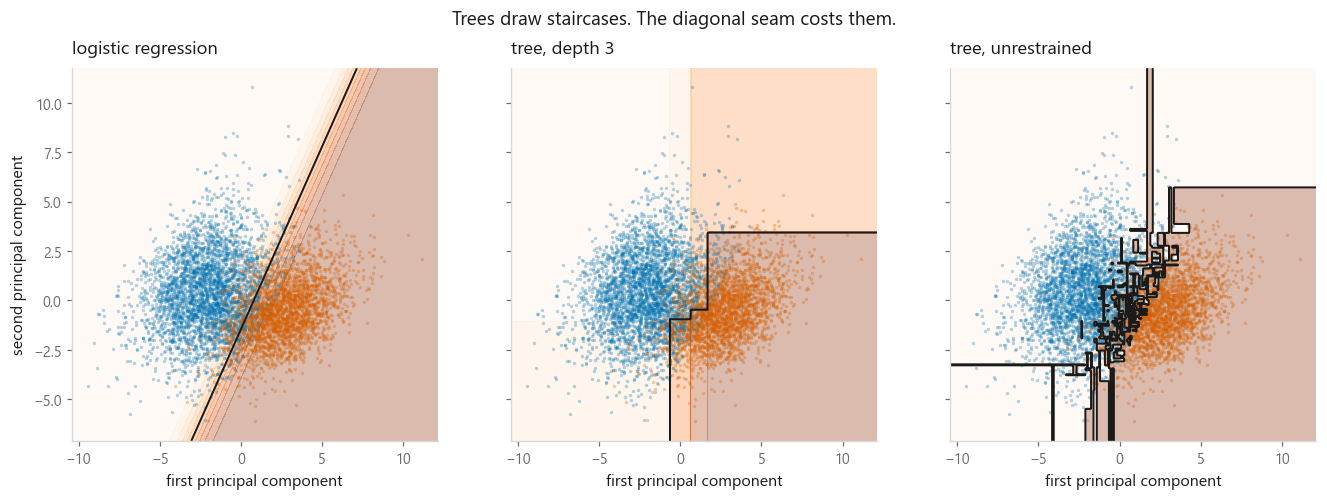

In [5]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pair = ["DERMASON", "SIRA"]
mask = y.isin(pair).values
flat = PCA(n_components=2, random_state=SEED).fit_transform(
    StandardScaler().fit_transform(X[mask]))
y_pair = (y[mask] == pair[1]).astype(int).values

step = 0.05
xx, yy = np.meshgrid(np.arange(flat[:, 0].min() - 1, flat[:, 0].max() + 1, step),
                     np.arange(flat[:, 1].min() - 1, flat[:, 1].max() + 1, step))
grid = np.c_[xx.ravel(), yy.ravel()]

drawn = {"logistic regression": LogisticRegression(max_iter=2000),
         "tree, depth 3": DecisionTreeClassifier(max_depth=3, random_state=SEED),
         "tree, unrestrained": DecisionTreeClassifier(random_state=SEED)}

fig, axes = plt.subplots(1, 3, figsize=(14.6, 4.4), sharex=True, sharey=True)
for ax, (name, estimator) in zip(axes, drawn.items()):
    estimator.fit(flat, y_pair)
    zz = estimator.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), cmap="Oranges", alpha=0.32)
    ax.contour(xx, yy, zz, levels=[0.5], colors=[style.INK], linewidths=1.3)
    for value, colour in [(0, style.PALETTE[0]), (1, style.HIGHLIGHT)]:
        sel = y_pair == value
        ax.scatter(flat[sel, 0], flat[sel, 1], s=5, alpha=0.30, c=colour, linewidths=0)
    ax.grid(False)
    ax.set_xlabel("first principal component")
    style.title(ax, name)

axes[0].set_ylabel("second principal component")
fig.suptitle("Trees draw staircases. The diagonal seam costs them.",
             x=0.5, y=1.00, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-staircase.png")

from sklearn.pipeline import make_pipeline

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)
contenders = [
    ("logistic regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))),
    ("tree, depth 6", DecisionTreeClassifier(max_depth=6, random_state=SEED)),
    ("tree, unrestrained", DecisionTreeClassifier(random_state=SEED)),
]

print("cross-validated accuracy on the full 16 features:")
for name, estimator in contenders:
    score = cross_val_score(estimator, X.values, y.values, cv=folds, n_jobs=-1).mean()
    print(f"  {name:<22}: {score:.4f}")

The depth-3 tree draws two or three steps and misses most of the seam. The
unrestrained tree follows it closely and then keeps going, carving small pockets
around individual beans: you can see them as islands of the wrong shade inside
each region. Those pockets are memorisation, and they are exactly what
[bagging](../../04-ensembles/01-bagging/) and
[random forests](../../04-ensembles/02-random-forest/) exist to average away.

A single tree is rarely the model you deploy. It is the model you *read*, and
the building block for the ensembles that follow.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You need to explain the decision to a human; features are mixed types; there are interactions and thresholds rather than smooth trends |
| **Avoid it when** | The boundary is diagonal or smooth; you need to extrapolate outside the training range; you want stability |
| **Scaling needed** | No. Splits are thresholds, so units do not matter |
| **Main dials** | `max_depth`, `min_samples_leaf`, `min_samples_split`, `ccp_alpha` for pruning |
| **Watch out** | Unconstrained trees always reach 100% training accuracy. They are also unstable: reshuffle the data and the tree changes shape |
| **Next** | [Bagging](../../04-ensembles/01-bagging/), which turns that instability into an advantage |

## What to remember

1. A split is chosen by maximising impurity removed, searching every feature and
   threshold. The search is greedy and never looks ahead.
2. Gini is 0 for a pure group and largest for an even mix.
3. Depth is the main dial. Unrestrained means memorised.
4. A tree's boundary is always a staircase of axis-aligned steps.
5. Read shallow trees; deploy ensembles of deep ones.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [04-01 Bagging](../../04-ensembles/01-bagging/) · Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#DecisionTree` `#CART` `#GiniImpurity` `#Classification`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#ExplainableAI`